In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
df = pd.read_csv('/content/Unemployment in India.csv')

In [3]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
df.shape

(768, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [6]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [7]:
df = df.dropna()

In [8]:
print(df.columns)

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [9]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


## Data Preview

The first five rows are displayed to understand the dataset structure and available columns.

In [10]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


## Statistical Summary

This summary provides information about the average, minimum, maximum, and distribution of numerical columns.

In [12]:
df[" Date"] = pd.to_datetime(df[" Date"])

/tmp/ipykernel_508/3108177301.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[" Date"] = pd.to_datetime(df[" Date"])


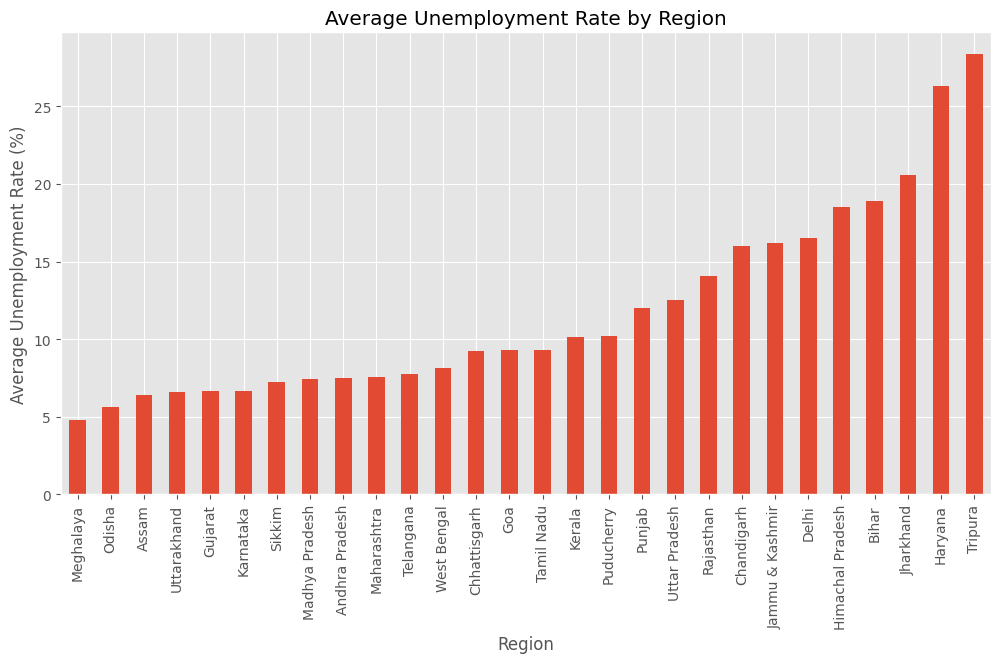

In [14]:
region_avg = df.groupby("Region")[" Estimated Unemployment Rate (%)"].mean().sort_values()

plt.figure(figsize=(12,6))
region_avg.plot(kind='bar')
plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=90)
plt.show()

### Observation

This chart shows the average unemployment rate across different regions. Some regions have significantly higher unemployment than others.

In [15]:
print(df.columns.tolist())

['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']


In [23]:
df.columns = df.columns.str.strip()

In [24]:
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [25]:
df['Date'] = pd.to_datetime(df['Date'])

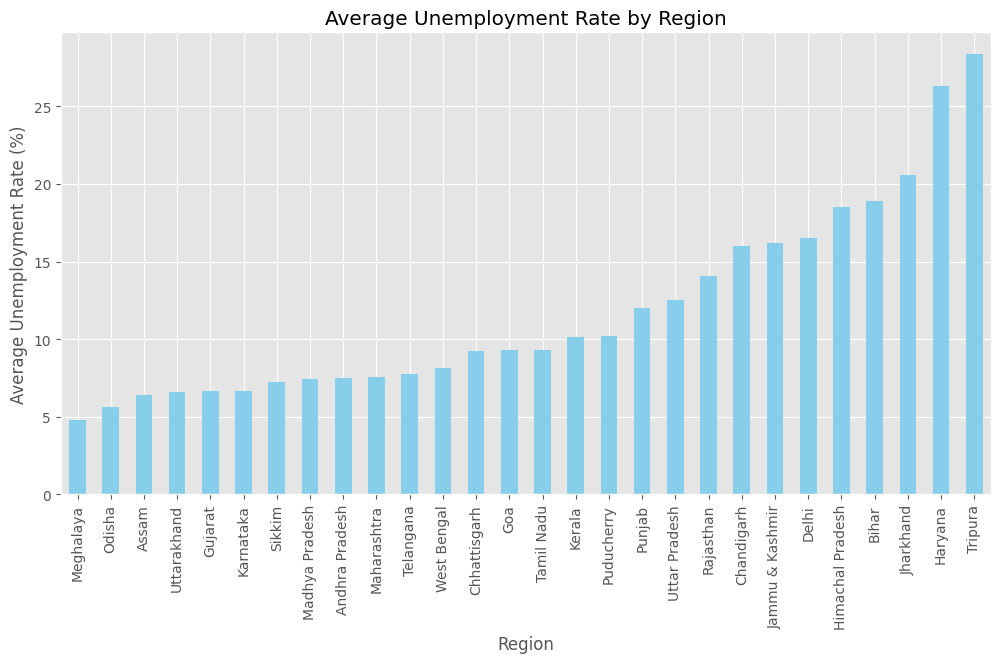

In [26]:
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values()

plt.figure(figsize=(12,6))
region_avg.plot(kind='bar', color='skyblue')

plt.title('Average Unemployment Rate by Region')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=90)

plt.show()


## Observation

This chart shows the average unemployment rate across different regions of India. Some regions have higher unemployment rates than others.

In [27]:
df['Month'] = df['Date'].dt.month_name()

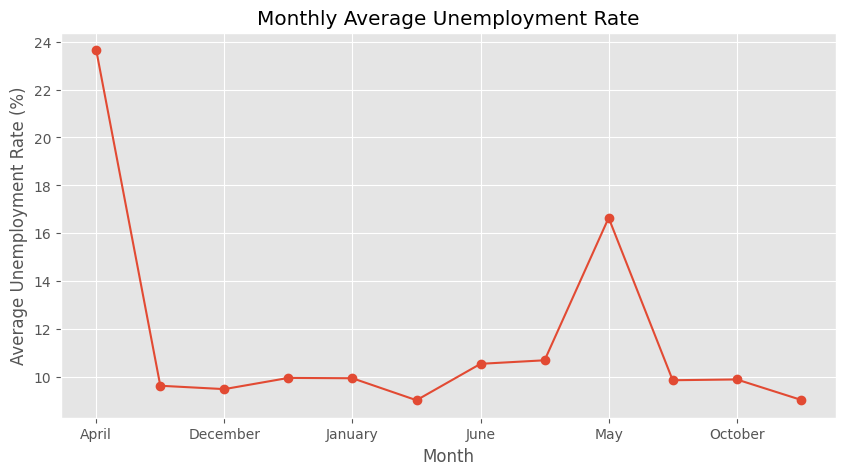

In [28]:
monthly = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(10,5))
monthly.plot(marker='o')

plt.title('Monthly Average Unemployment Rate')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')

plt.grid(True)
plt.show()

## Observation

The unemployment rate varies across different months, showing seasonal and economic fluctuations.

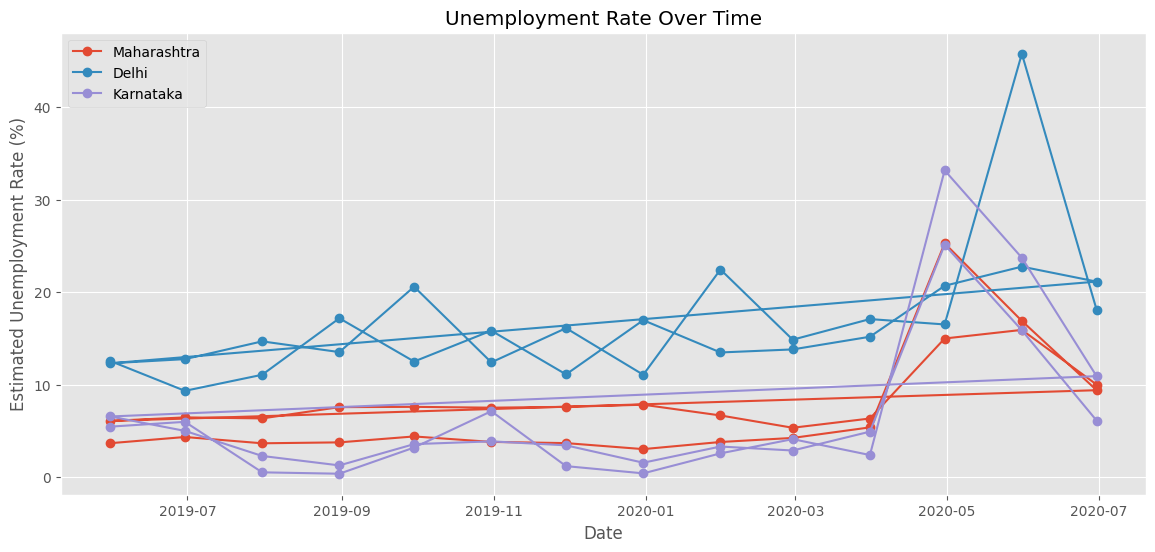

In [29]:
states = ['Maharashtra', 'Delhi', 'Karnataka']

plt.figure(figsize=(14,6))

for state in states:
    state_data = df[df['Region'] == state]
    plt.plot(state_data['Date'],
             state_data['Estimated Unemployment Rate (%)'],
             marker='o',
             label=state)

plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Estimated Unemployment Rate (%)")
plt.legend()
plt.grid(True)
plt.show()

The line chart compares unemployment trends in Maharashtra, Delhi, and Karnataka over time. The unemployment rate increased significantly during the COVID-19 period, with different recovery patterns across states.

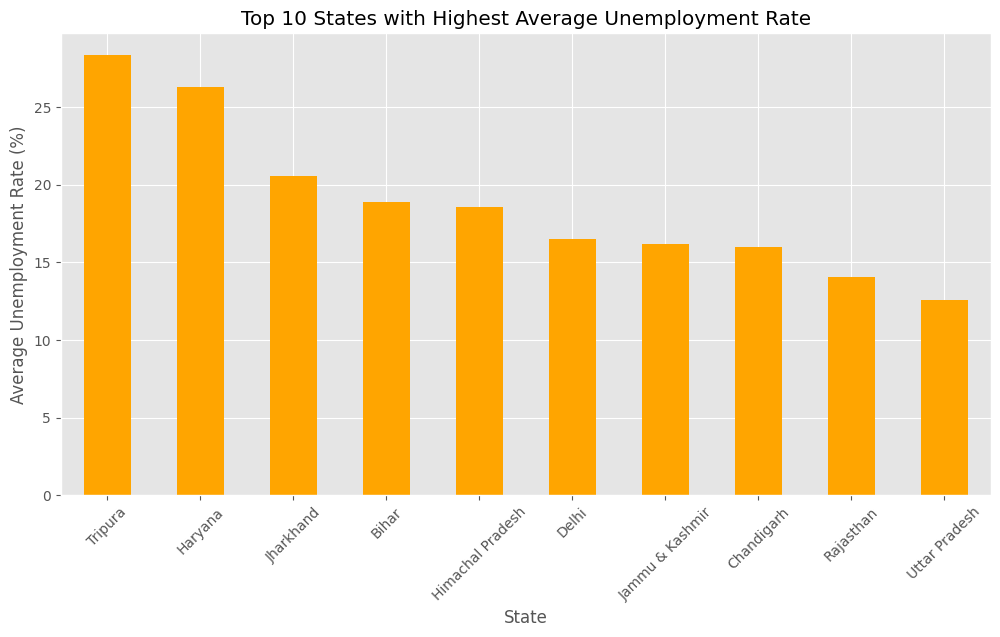

In [30]:
top10 = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

top10.plot(kind='bar', color='orange')

plt.title("Top 10 States with Highest Average Unemployment Rate")
plt.xlabel("State")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)

plt.show()

## Observation

The chart highlights the ten states with the highest average unemployment rates. These states experienced comparatively greater employment challenges.

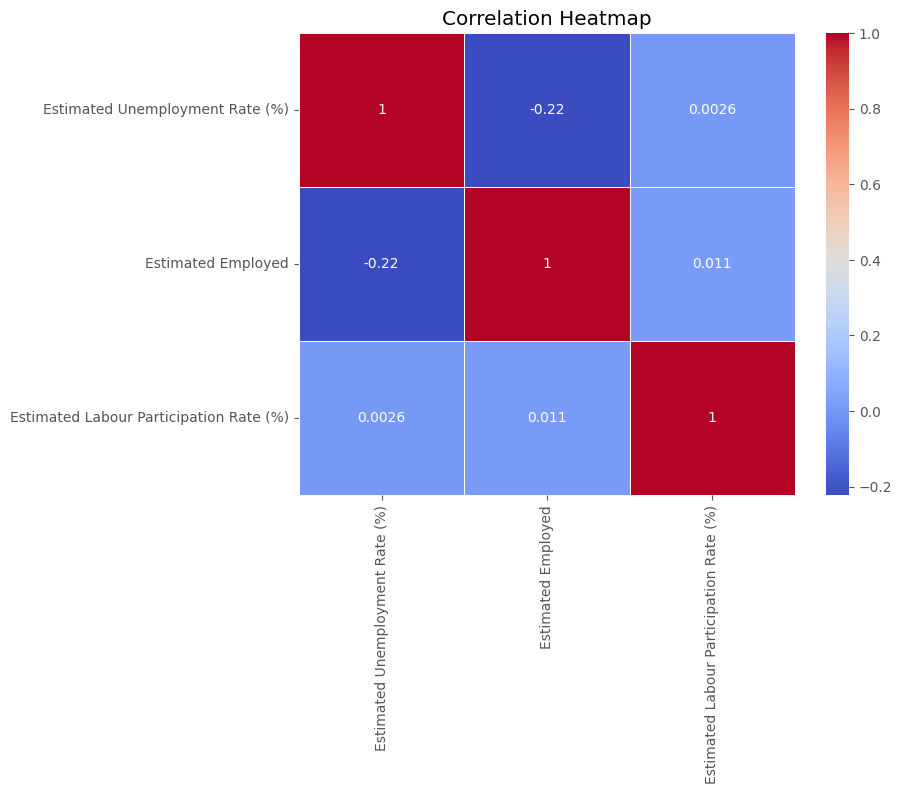

In [31]:
plt.figure(figsize=(8,6))

corr = df[['Estimated Unemployment Rate (%)',
           'Estimated Employed',
           'Estimated Labour Participation Rate (%)']].corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

## Observation

The heatmap shows the correlation between unemployment rate, employment, and labour participation rate. Positive values indicate a direct relationship, while negative values indicate an inverse relationship.

In [32]:
covid_date = '2020-03-01'

pre_covid = df[df['Date'] < covid_date]
post_covid = df[df['Date'] >= covid_date]

print("Average Unemployment Rate Before COVID:")
print(pre_covid['Estimated Unemployment Rate (%)'].mean())

print("\nAverage Unemployment Rate After COVID:")
print(post_covid['Estimated Unemployment Rate (%)'].mean())

Average Unemployment Rate Before COVID:
9.509533582089553

Average Unemployment Rate After COVID:
17.774362745098042


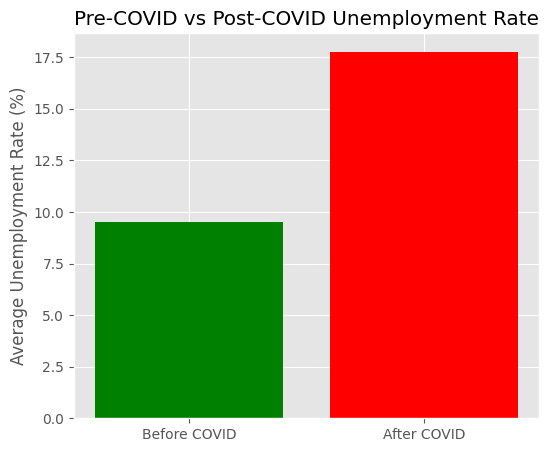

In [33]:
before = pre_covid['Estimated Unemployment Rate (%)'].mean()
after = post_covid['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(6,5))

plt.bar(['Before COVID','After COVID'],
        [before, after],
        color=['green','red'])

plt.title("Pre-COVID vs Post-COVID Unemployment Rate")
plt.ylabel("Average Unemployment Rate (%)")

plt.show()

## Observation

The average unemployment rate increased after the COVID-19 outbreak, showing the pandemic's significant impact on employment in India.

# Conclusion

This analysis explored unemployment trends in India using Python.

Key findings include:

- Unemployment rates vary across different regions.
- Monthly unemployment trends show noticeable fluctuations.
- Some states experienced significantly higher unemployment than others.
- The correlation heatmap revealed relationships between unemployment, employment, and labour participation.
- The comparison between pre-COVID and post-COVID periods shows that unemployment increased after the pandemic, highlighting its impact on the Indian labour market.

Overall, the analysis demonstrates how data visualization and exploratory data analysis can help understand employment patterns and economic changes.